<a href="https://colab.research.google.com/github/Amal-Joshy-T/ML-and-DL-Projects/blob/main/Customer%20Churn%20Prediction/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **📌 Problem Statement**

Customer churn is a major challenge for subscription-based and telecom businesses, as losing customers directly impacts revenue and long-term growth. Acquiring new customers is significantly more expensive than retaining existing ones, making churn prediction a critical business priority.

The objective of this project is to develop an end-to-end Customer Churn Prediction System using Machine Learning and Deep Learning techniques on a large dataset of over 60,000 customer records. The system aims to analyze customer demographic details, service usage patterns, billing information, and contract-related features to accurately predict whether a customer is likely to churn.

By performing data preprocessing, feature engineering, handling class imbalance, and implementing advanced predictive models, the goal is to identify high-risk customers early. Additionally, the project seeks to uncover key churn drivers—such as contract type, tenure, payment method, and monthly charges—and provide actionable business insights, including revenue-at-risk analysis, to support data-driven customer retention strategies.

---



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/project data sets/customer_churn_60000_high_accuracy.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST000001,Female,0,Yes,No,51,Fiber optic,Month-to-month,Bank transfer,40.20,2090.12,Yes
1,CUST000002,Male,0,Yes,No,60,Fiber optic,One year,Mailed check,114.62,6854.88,Yes
2,CUST000003,Female,0,No,No,51,DSL,Month-to-month,Bank transfer,82.25,4203.57,Yes
3,CUST000004,Male,1,No,No,19,Fiber optic,Two year,Electronic check,102.46,1998.55,Yes
4,CUST000005,Female,0,No,No,2,Fiber optic,Month-to-month,Mailed check,86.50,192.88,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       60000 non-null  object 
 1   gender           60000 non-null  object 
 2   SeniorCitizen    60000 non-null  int64  
 3   Partner          60000 non-null  object 
 4   Dependents       60000 non-null  object 
 5   tenure           60000 non-null  int64  
 6   InternetService  60000 non-null  object 
 7   Contract         60000 non-null  object 
 8   PaymentMethod    60000 non-null  object 
 9   MonthlyCharges   60000 non-null  float64
 10  TotalCharges     60000 non-null  float64
 11  Churn            60000 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.5+ MB


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
InternetService,0
Contract,0
PaymentMethod,0
MonthlyCharges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

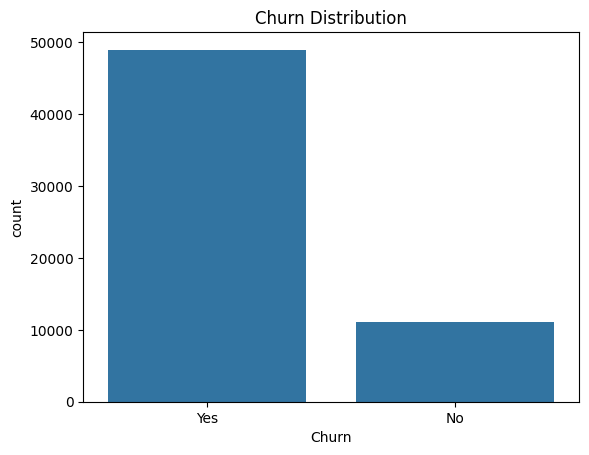

In [ ]:

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

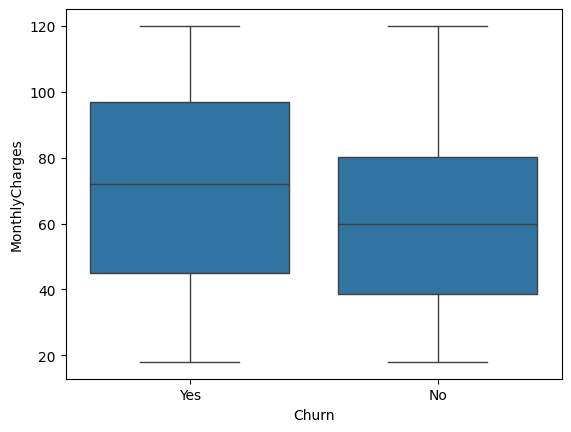

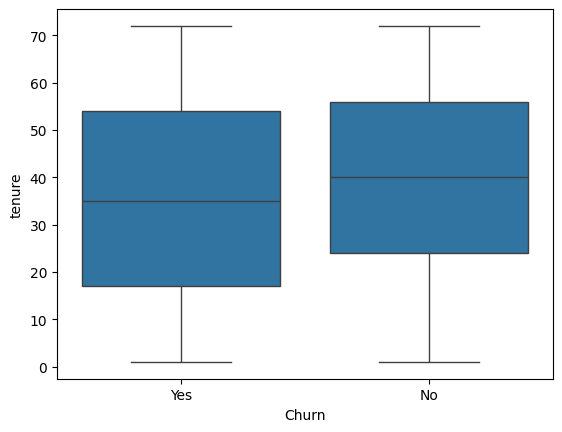

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       60000 non-null  object 
 1   gender           60000 non-null  object 
 2   SeniorCitizen    60000 non-null  int64  
 3   Partner          60000 non-null  object 
 4   Dependents       60000 non-null  object 
 5   tenure           60000 non-null  int64  
 6   InternetService  60000 non-null  object 
 7   Contract         60000 non-null  object 
 8   PaymentMethod    60000 non-null  object 
 9   MonthlyCharges   60000 non-null  float64
 10  TotalCharges     60000 non-null  float64
 11  Churn            60000 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.5+ MB


In [ ]:
df['customerID'].unique()

array(['CUST000001', 'CUST000002', 'CUST000003', ..., 'CUST059998',
       'CUST059999', 'CUST060000'], dtype=object)

In [ ]:
df.drop(['customerID'], axis=1, inplace=True)

In [ ]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df['gender'].replace({'Male':1,'Female':0},inplace=True)

/tmp/ipython-input-1871157913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'Male':1,'Female':0},inplace=True)
/tmp/ipython-input-1871157913.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace({'Male':1,'Female':0},inplace=True)


In [ ]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Partner'].replace({'Yes':1,'No':0},inplace=True)

/tmp/ipython-input-1523588084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Partner'].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipython-input-1523588084.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Partner'].replace({'Yes':1,'No':0},inplace=True)


In [ ]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['Dependents'].replace({'Yes':1,'No':0},inplace=True)

/tmp/ipython-input-3048209067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipython-input-3048209067.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Dependents'].replace({'Yes':1,'No':0},inplace=True)


In [ ]:
df['InternetService'].unique()

array(['Fiber optic', 'DSL', 'No'], dtype=object)

In [ ]:
dummies=pd.get_dummies(df['InternetService']).astype(int)

In [ ]:
df = pd.concat([df,dummies],axis="columns")

In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
dummies=pd.get_dummies(df['Contract']).astype(int)


In [ ]:
df = pd.concat([df,dummies],axis="columns")

In [ ]:
df['PaymentMethod'].unique()

array(['Bank transfer', 'Mailed check', 'Electronic check', 'Credit card'],
      dtype=object)

In [ ]:
dummies=pd.get_dummies(df['PaymentMethod']).astype(int)

In [ ]:
df = pd.concat([df,dummies],axis="columns")

In [ ]:
df['Churn'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Churn'].replace({'Yes':1,'No':0},inplace=True)

/tmp/ipython-input-2244520575.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Churn'].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipython-input-2244520575.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'].replace({'Yes':1,'No':0},inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            60000 non-null  int64  
 1   SeniorCitizen     60000 non-null  int64  
 2   Partner           60000 non-null  int64  
 3   Dependents        60000 non-null  int64  
 4   tenure            60000 non-null  int64  
 5   InternetService   60000 non-null  object 
 6   Contract          60000 non-null  object 
 7   PaymentMethod     60000 non-null  object 
 8   MonthlyCharges    60000 non-null  float64
 9   TotalCharges      60000 non-null  float64
 10  Churn             60000 non-null  int64  
 11  DSL               60000 non-null  int64  
 12  Fiber optic       60000 non-null  int64  
 13  No                60000 non-null  int64  
 14  Month-to-month    60000 non-null  int64  
 15  One year          60000 non-null  int64  
 16  Two year          60000 non-null  int64 

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,...,DSL,Fiber optic,No,Month-to-month,One year,Two year,Bank transfer,Credit card,Electronic check,Mailed check
0,0,0,1,0,51,Fiber optic,Month-to-month,Bank transfer,40.20,2090.12,...,0,1,0,1,0,0,1,0,0,0
1,1,0,1,0,60,Fiber optic,One year,Mailed check,114.62,6854.88,...,0,1,0,0,1,0,0,0,0,1
2,0,0,0,0,51,DSL,Month-to-month,Bank transfer,82.25,4203.57,...,1,0,0,1,0,0,1,0,0,0
3,1,1,0,0,19,Fiber optic,Two year,Electronic check,102.46,1998.55,...,0,1,0,0,0,1,0,0,1,0
4,0,0,0,0,2,Fiber optic,Month-to-month,Mailed check,86.50,192.88,...,0,1,0,1,0,0,0,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            60000 non-null  int64  
 1   SeniorCitizen     60000 non-null  int64  
 2   Partner           60000 non-null  int64  
 3   Dependents        60000 non-null  int64  
 4   tenure            60000 non-null  int64  
 5   InternetService   60000 non-null  object 
 6   Contract          60000 non-null  object 
 7   PaymentMethod     60000 non-null  object 
 8   MonthlyCharges    60000 non-null  float64
 9   TotalCharges      60000 non-null  float64
 10  Churn             60000 non-null  int64  
 11  DSL               60000 non-null  int64  
 12  Fiber optic       60000 non-null  int64  
 13  No                60000 non-null  int64  
 14  Month-to-month    60000 non-null  int64  
 15  One year          60000 non-null  int64  
 16  Two year          60000 non-null  int64 

In [ ]:
df.drop(['InternetService','Contract','PaymentMethod'],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            60000 non-null  int64  
 1   SeniorCitizen     60000 non-null  int64  
 2   Partner           60000 non-null  int64  
 3   Dependents        60000 non-null  int64  
 4   tenure            60000 non-null  int64  
 5   MonthlyCharges    60000 non-null  float64
 6   TotalCharges      60000 non-null  float64
 7   Churn             60000 non-null  int64  
 8   DSL               60000 non-null  int64  
 9   Fiber optic       60000 non-null  int64  
 10  No                60000 non-null  int64  
 11  Month-to-month    60000 non-null  int64  
 12  One year          60000 non-null  int64  
 13  Two year          60000 non-null  int64  
 14  Bank transfer     60000 non-null  int64  
 15  Credit card       60000 non-null  int64  
 16  Electronic check  60000 non-null  int64 

In [ ]:
from imblearn.over_sampling import SMOTE


X = df.drop('Churn', axis=1)
y = df['Churn']

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
import pandas as pd

df_cleaned = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="'Churn'")],
    axis=1
)


In [ ]:
df=df_cleaned

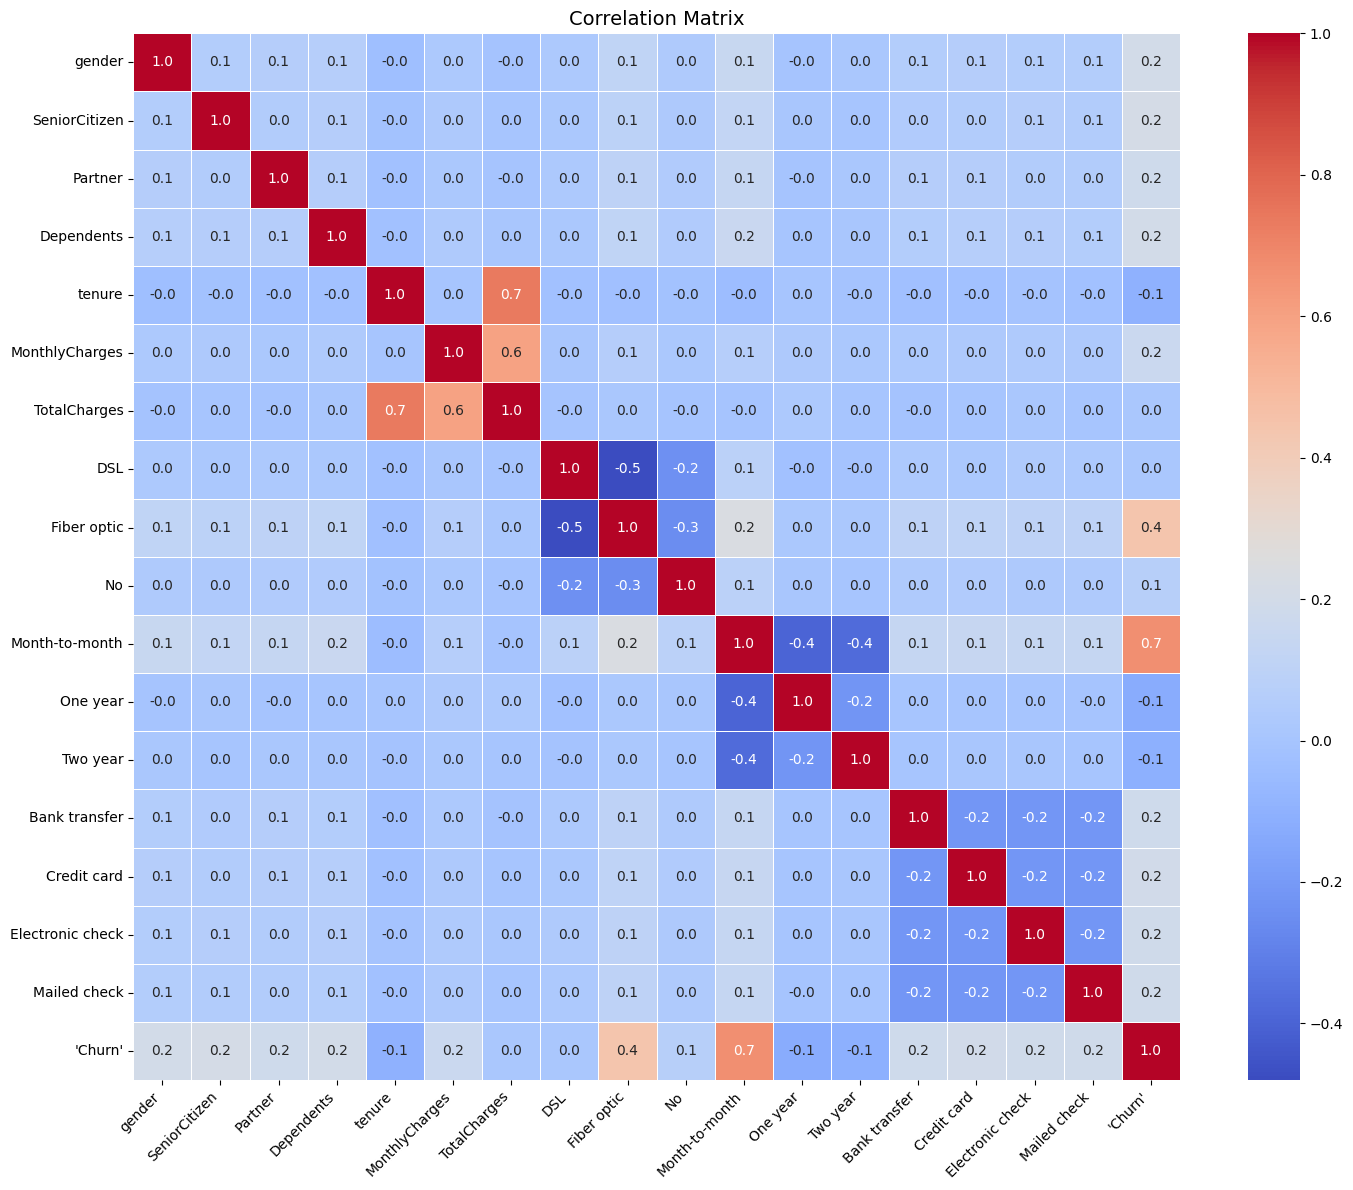

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".01f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

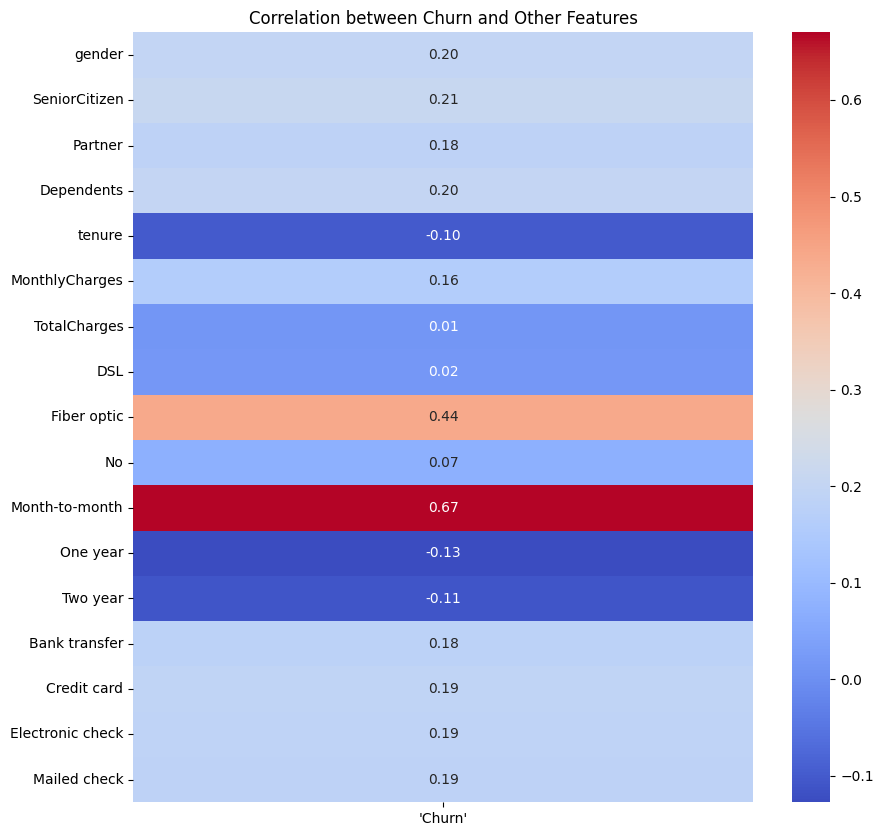

In [ ]:
Churn_corr = df.corr()["'Churn'"]


Churn_corr = Churn_corr.drop("'Churn'")
plt.figure(figsize=(10, 10))
sns.heatmap(Churn_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Churn and Other Features')

plt.show()

In [ ]:
df.drop(['TotalCharges','DSL','No'],axis=1,inplace=True)

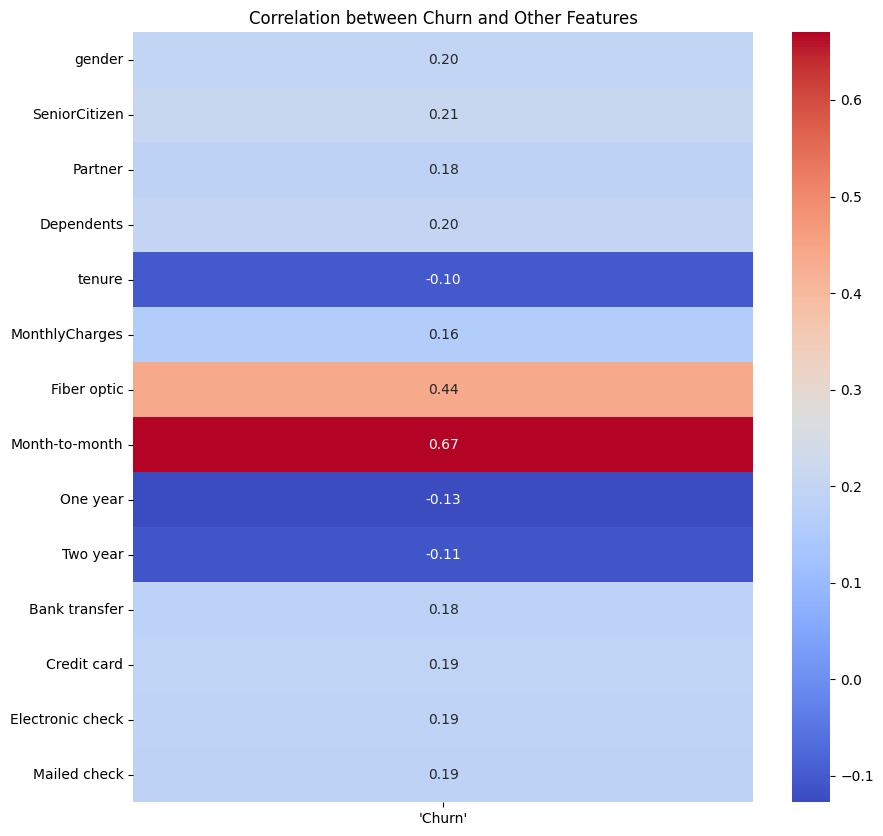

In [ ]:
Churn_corr = df.corr()["'Churn'"]


Churn_corr = Churn_corr.drop("'Churn'")
plt.figure(figsize=(10, 10))
sns.heatmap(Churn_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Churn and Other Features')

plt.show()

In [ ]:
df.drop(['tenure','One year','Two year'],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97908 entries, 0 to 97907
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            97908 non-null  int64  
 1   SeniorCitizen     97908 non-null  int64  
 2   Partner           97908 non-null  int64  
 3   Dependents        97908 non-null  int64  
 4   MonthlyCharges    97908 non-null  float64
 5   Fiber optic       97908 non-null  int64  
 6   Month-to-month    97908 non-null  int64  
 7   Bank transfer     97908 non-null  int64  
 8   Credit card       97908 non-null  int64  
 9   Electronic check  97908 non-null  int64  
 10  Mailed check      97908 non-null  int64  
 11  'Churn'           97908 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 9.0 MB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
X=df.drop(columns=["'Churn'"])
y=df["'Churn'"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.84


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=10000,  # Increased max_iter to allow more convergence attempts
    random_state=42
)

svclassifier.fit(X_train_scaled, y_train)
svclassifier.score(X_test_scaled, y_test)
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.85


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()

In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.8874091020508211


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.8826701527902606


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 5 Accuracy: 0.8847850956038569
Fold 6 Accuracy: 0.8812714495832652


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 7 Accuracy: 0.8856022225853898
Fold 8 Accuracy: 0.8812714495832652

 Best Fold: 1 with Accuracy: 0.8874091020508211


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8874091020508211

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8459841490317836

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8492523899011357

In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(best_X_train,best_y_train)
svclassifier.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.6654955470218155

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(best_X_train.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(best_X_train,best_y_train,epochs=90,batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8673 - loss: 0.2903
Epoch 2/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8831 - loss: 0.2485
Epoch 3/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8859 - loss: 0.2428
Epoch 4/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8837 - loss: 0.2457
Epoch 5/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8821 - loss: 0.2481
Epoch 6/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8844 - loss: 0.2426
Epoch 7/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8828 - loss: 0.2457
Epoch 8/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8862 - loss: 0.2430
Epoch 9/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8847 - loss: 0.2429
Epoch 10/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8843 - loss: 0.2440
Epoch 11/90
2142/2142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8852 - loss: 0.2437
Epoch 12/90
2142/2142 ━━━━━━━━

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8879 - loss: 0.2388
model accuracy:88.53%


In [ ]:
import pickle
with open("churn  deepmodel.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/churn  deepmodel.pkl","rb") as file:
  load_model=pickle.load(file)

# **Conclusion**

An end-to-end customer churn prediction system was developed using machine learning and deep learning techniques on a dataset of over 60,000 customer records. After data preprocessing and feature engineering, the deep learning model achieved 88.53% accuracy, effectively capturing complex customer behavior patterns. Exploratory analysis and model explainability highlighted key churn drivers such as contract type, tenure, payment method, and monthly charges, while a revenue-at-risk analysis supported business-focused retention strategies.